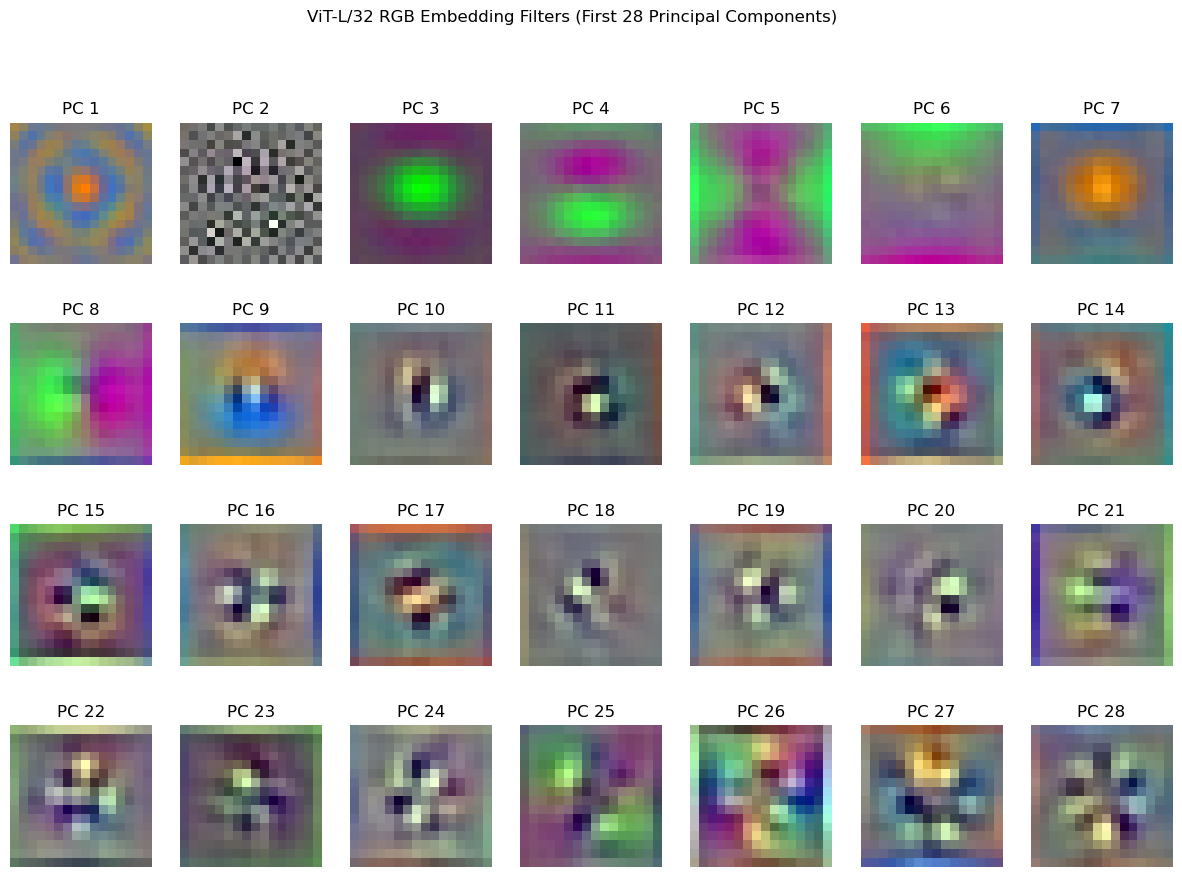

前 28 个主成分解释的总方差比例: 49.91%


"\n# 可视化前 28 个主成分的权重映射\nplt.figure(figsize=(14, 8))\nfor i in range(28):\n    plt.subplot(4, 7, i + 1)  # 4x7的子图布局\n    plt.imshow(principal_components[i].reshape(24, 32), cmap='coolwarm', aspect='auto')\n    plt.title(f'PC {i+1}')\n    plt.axis('off')\n\nplt.suptitle('Top 28 Principal Components of ViT Embedding Filters')\nplt.show()\n"

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import ViTModel
from sklearn.decomposition import PCA

# 加载ViT模型
model_name = 'google/vit-base-patch16-224-in21k'
model = ViTModel.from_pretrained(model_name)

# 获取嵌入层的权重，形状为 [768, 3, 16, 16]
embedding_weights = model.embeddings.patch_embeddings.projection.weight.detach().cpu().numpy()

# 将权重展平为 [768, 3*16*16] => [768, 768]
embedding_weights_flat = embedding_weights.reshape(embedding_weights.shape[0], -1)

# 执行 PCA，提取前 28 个主成分
pca = PCA(n_components=28)
principal_components = pca.fit_transform(embedding_weights_flat)  # 结果形状: [768, 28]

# 转置，使得每个主成分成为一列 [28, 768]
# principal_components = principal_components.T  

# 5. 获取前 28 个主成分并恢复形状以进行可视化
principal_filters = pca.components_.reshape(n_components, 3, 16, 16)

# 6. 可视化前 28 个主成分嵌入滤波器
fig, axes = plt.subplots(4, 7, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    filter_img = np.transpose(principal_filters[i], (1, 2, 0))  # 转换为 HxWxC (32x32x3)
    filter_img -= filter_img.min()  # 归一化到 [0, 1]
    filter_img /= filter_img.max()
    
    ax.imshow(filter_img)
    ax.set_title(f"PC {i+1}")
    ax.axis("off")

plt.suptitle("ViT-L/32 RGB Embedding Filters (First 28 Principal Components)")
plt.show()

# 7. 输出解释方差比例
explained_variance = pca.explained_variance_ratio_
print(f"前 28 个主成分解释的总方差比例: {sum(explained_variance) * 100:.2f}%")




'''
# 可视化前 28 个主成分的权重映射
plt.figure(figsize=(14, 8))
for i in range(28):
    plt.subplot(4, 7, i + 1)  # 4x7的子图布局
    plt.imshow(principal_components[i].reshape(24, 32), cmap='coolwarm', aspect='auto')
    plt.title(f'PC {i+1}')
    plt.axis('off')

plt.suptitle('Top 28 Principal Components of ViT Embedding Filters')
plt.show()
'''